In [132]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestRegressor


In [133]:
#Import Data
df = pd.read_csv('2025SireLinesUpdate_SYNTHETIC.csv')


In [134]:
#Data Prep - OneHotEncoding for categorical
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X = pd.get_dummies(X, drop_first= True)

In [135]:
#Splitting the Dataset
X_train , X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

#Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

c:\Users\david.kim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\extmath.py:1211: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\david.kim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\extmath.py:1216: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\Users\david.kim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\extmath.py:1240: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [136]:
#Random Forest Regressor - to find model variation
regressor = RandomForestRegressor(n_estimators = 100, random_state=42)
regressor.fit(X_train, y_train)
y_pred = regressor.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}") #average magnitude of errors
print(f'RMSE: {rmse:.2f}') #Root mean square error, measures how far predicted values are from actual values
print(f"R^2 Score: {r2:.2f}")  #model explains most of the variation in the dependent variable

MAE: 33.51
RMSE: 366.87
R^2 Score: 0.95



**R^2 = 0.99**: 99 percent of variance in dependent variables is explained by the independent variables

In [137]:
#Categories
df.columns

Index(['CompanyId', 'ProducerName', 'Producer Size', 'SiteName', 'groupid',
       'Groupname', 'CombinedGroupName', 'Std Cost/Lb Gain', 'GroupType',
       'BusinessUnitName', 'DateFirstEntered', 'PARITY', 'PARITYGROUP',
       'StartPigsInterval', 'TotalPigsIn', 'TotalPigsInWeight',
       'AvgPigsInWeight', 'TotalPigsProduced', 'AvgExitPigWeight',
       'TotalStdPigs', 'PercentStdPigs', 'TotalStdPigWt', 'AvgStdPigWt',
       'TotalSubStdPigs', 'PercentSubStdPigs', 'TotalSubStdPigWt',
       'AvgSubStdPigWt', 'NetWtProduced', 'Adg', 'TotalFeed',
       'FeedLbsPerPigProduced', 'GroupCloseDate', 'Gender', 'MONTH', 'QTR',
       'YEAR', 'HealthStatus', 'CLEAN/DIRTY', 'AvgWtOutWODeadWt',
       'TransferPercOut', 'MarketSalesPercOut', 'GeneticSalesPercOut',
       'OtherSalesPercOut', 'AdjustmentPercOut', 'FEED COST/TON',
       'FeedCostlbGain', 'MortalityPercPigsIn', 'FC', 'AdjFC', 'Adfi',
       'PigsProduced', 'LocationDays', 'AvgDof', 'Dof', 'ServiceTechName',
       'PigFlow', 'G

          count      mean    median        st       min       max
SIRELINE                                                         
PIC 337      92  0.061506  0.058636  0.024588  0.021737  0.120709
DNA 610     356  0.071203  0.058424  0.043061  0.012341  0.365281
PIC 800     644  0.076733  0.062737  0.055729  0.011024  0.562121
TN-DUROC     66  0.110617  0.094410  0.060313  0.026981  0.273997


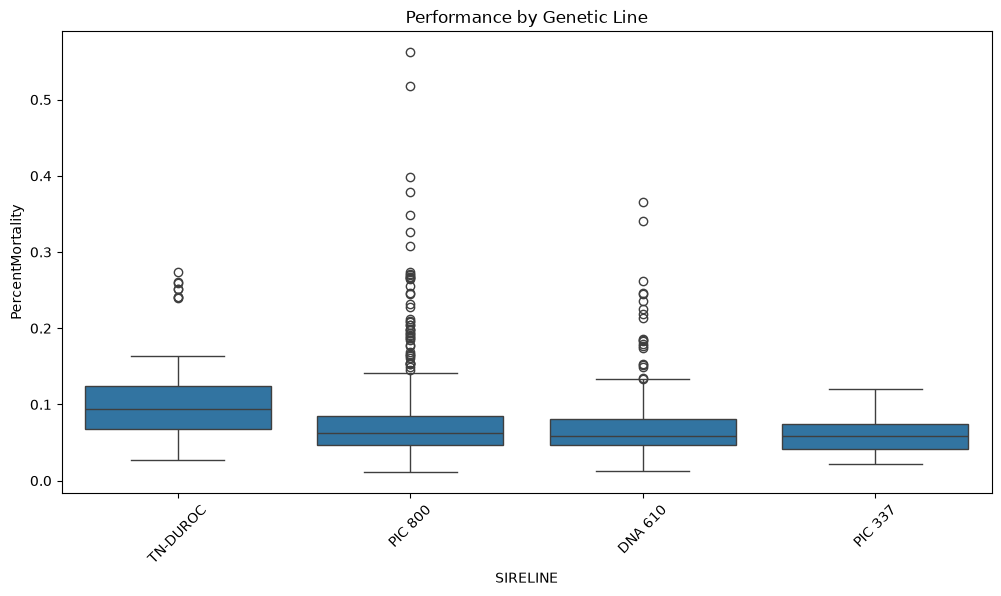

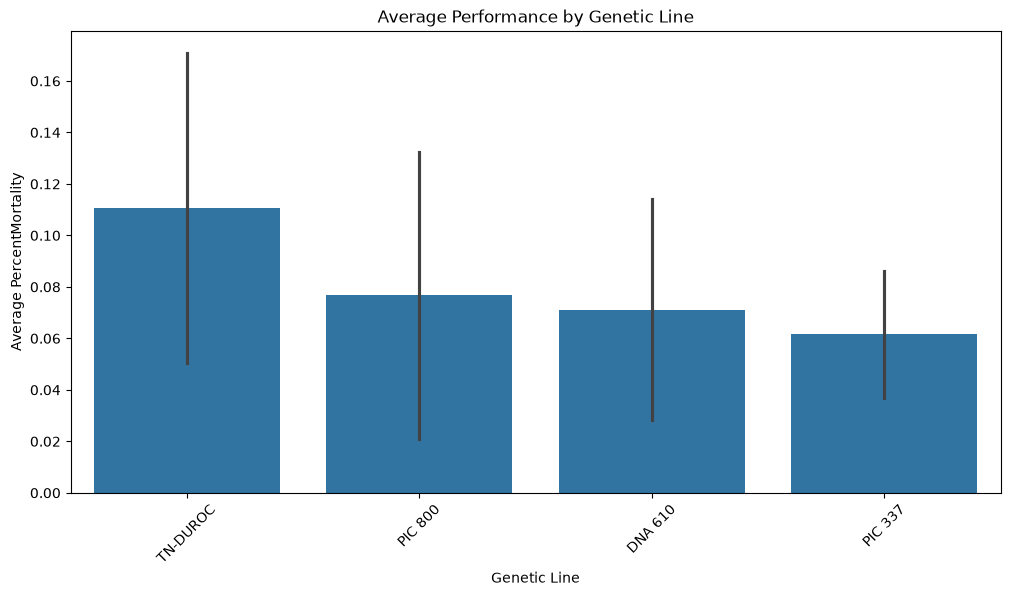

F-statistic: 13.95304398224835
p-value: 6.120233282703152e-09
          count      mean    median       std
SIRELINE                                     
PIC 337      92  0.061506  0.058636  0.024588
DNA 610     356  0.071203  0.058424  0.043061
PIC 800     644  0.076733  0.062737  0.055729
TN-DUROC     66  0.110617  0.094410  0.060313
Best genetic line PIC 337
          count      mean    median       std
SIRELINE                                     
PIC 337      92  0.061506  0.058636  0.024588


In [138]:
#Genetic Line Comparisons - Percent Mortality

genetic_col = "SIRELINE"
target_col = "PercentMortality"

line_summary = df.groupby(genetic_col)[target_col].agg(
    count = 'count',
    mean = 'mean',
    median = 'median',
    st = 'std',
    min = 'min',
    max = 'max',
).sort_values(by = 'mean', ascending=True)
print(line_summary)

#Visualization
plt.figure(figsize = (12,6))
sns.boxplot(data = df, x = genetic_col, y = target_col)
plt.title("Performance by Genetic Line")
plt.ylabel(target_col)
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=df, x=genetic_col, y=target_col, errorbar="sd")
plt.title("Average Performance by Genetic Line")
plt.xlabel("Genetic Line")
plt.ylabel(f"Average {target_col}")
plt.xticks(rotation=45)
plt.show()

#Testing whether statistically significant
from scipy.stats import f_oneway

groups = [
    group[target_col].dropna()
    for name, group in df.groupby(genetic_col)
]

f_stat1, p_value1 = f_oneway(*groups)


print("F-statistic:", f_stat1)
print("p-value:", p_value1) 

#Summary of Genetic Lines
line_summary1 = df.groupby(genetic_col)[target_col].agg(
    count="count",
    mean="mean",
    median="median",
    std="std"
)
line_summary1 = line_summary1[line_summary1["count"] >= 5]

line_summary1 = line_summary1.sort_values(by="mean", ascending=True)


print(line_summary1)

best_line = line_summary1.index[0]
print("Best genetic line", best_line)


#top performer
print(line_summary1.head(1))

          count      mean    median        st       min       max
SIRELINE                                                         
DNA 610     356  1.795199  1.794413  0.127109  1.479513  2.143389
PIC 337      92  1.770794  1.767325  0.120349  1.461511  2.033191
PIC 800     644  1.733315  1.735492  0.131837  1.247481  2.194783
TN-DUROC     66  1.703422  1.717416  0.111421  1.360630  1.966237


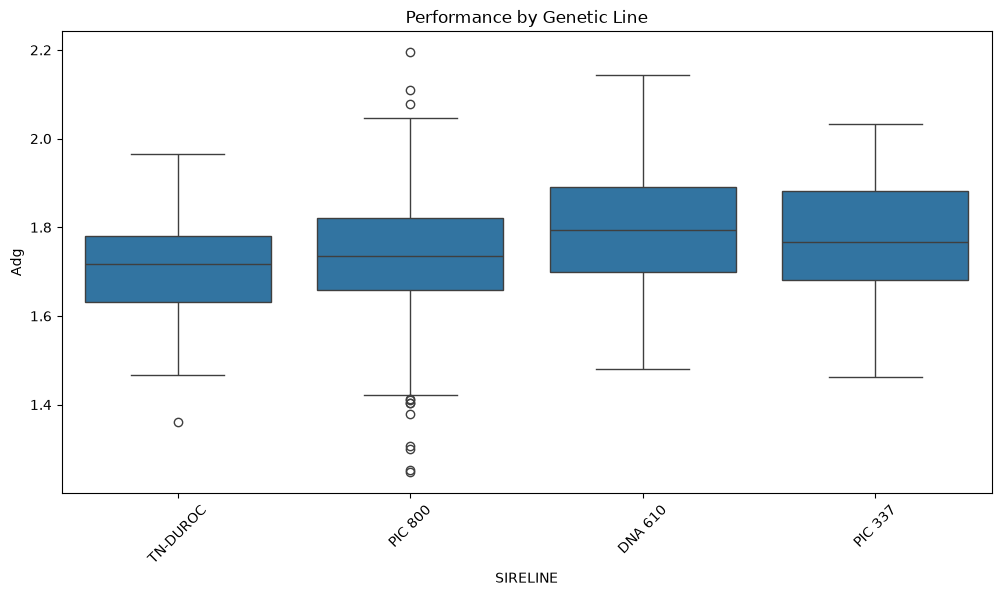

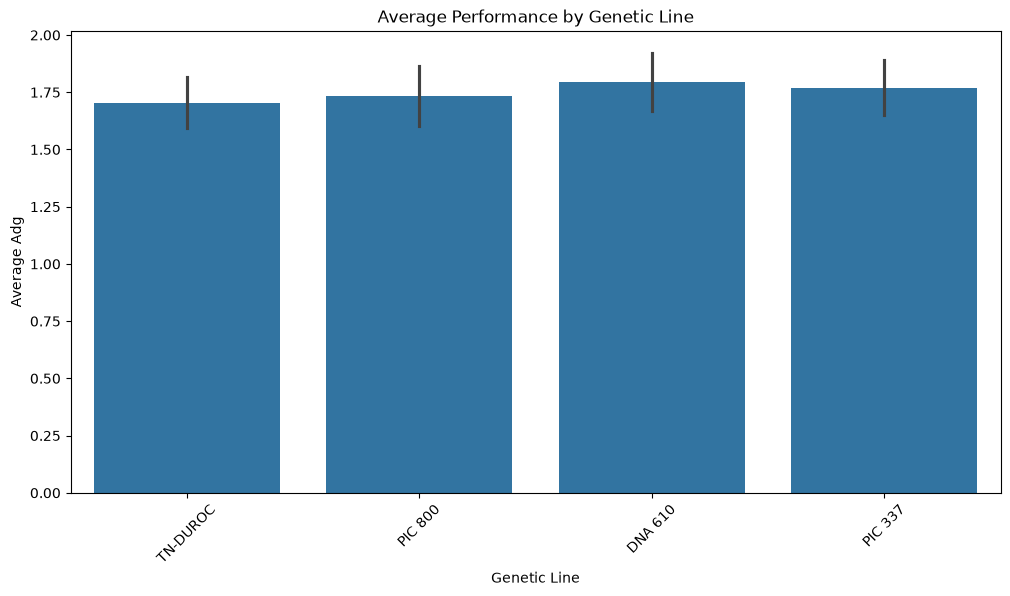

F-statistic: 21.710214372760728
p-value: 1.1103540367109733e-13
          count      mean    median       std
SIRELINE                                     
DNA 610     356  1.795199  1.794413  0.127109
PIC 337      92  1.770794  1.767325  0.120349
PIC 800     644  1.733315  1.735492  0.131837
TN-DUROC     66  1.703422  1.717416  0.111421
Best genetic line DNA 610
          count      mean    median       std
SIRELINE                                     
DNA 610     356  1.795199  1.794413  0.127109


In [139]:
#Genetic Line Comparisons - Average Daily Gain

genetic_col = "SIRELINE"
target_col = "Adg"

line_summary = df.groupby(genetic_col)[target_col].agg(
    count = 'count',
    mean = 'mean',
    median = 'median',
    st = 'std',
    min = 'min',
    max = 'max',
).sort_values(by = 'mean', ascending=False)
print(line_summary)

#Visualization
plt.figure(figsize = (12,6))
sns.boxplot(data = df, x = genetic_col, y = target_col)
plt.title("Performance by Genetic Line")
plt.ylabel(target_col)
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=df, x=genetic_col, y=target_col, errorbar="sd")
plt.title("Average Performance by Genetic Line")
plt.xlabel("Genetic Line")
plt.ylabel(f"Average {target_col}")
plt.xticks(rotation=45)
plt.show()

#Testing whether statistically significant
from scipy.stats import f_oneway

groups = [
    group[target_col].dropna()
    for name, group in df.groupby(genetic_col)
]

f_stat2, p_value2 = f_oneway(*groups)


print("F-statistic:", f_stat2)
print("p-value:", p_value2) 

#Summary of Genetic Lines
line_summary2 = df.groupby(genetic_col)[target_col].agg(
    count="count",
    mean="mean",
    median="median",
    std="std"
)
line_summary2 = line_summary2[line_summary2["count"] >= 5]

line_summary2 = line_summary2.sort_values(by="mean", ascending=False)


print(line_summary2)

best_line = line_summary2.index[0]
print("Best genetic line", best_line)


#top performer
print(line_summary2.head(1))

          count      mean    median        st       min       max
SIRELINE                                                         
DNA 610     356  2.471231  2.463591  0.163122  1.929698  2.959523
PIC 337      92  2.474529  2.478935  0.143412  2.021256  2.880726
TN-DUROC     66  2.499152  2.480255  0.199172  2.183836  2.989408
PIC 800     644  2.535578  2.515701  0.176872  1.891229  3.419248


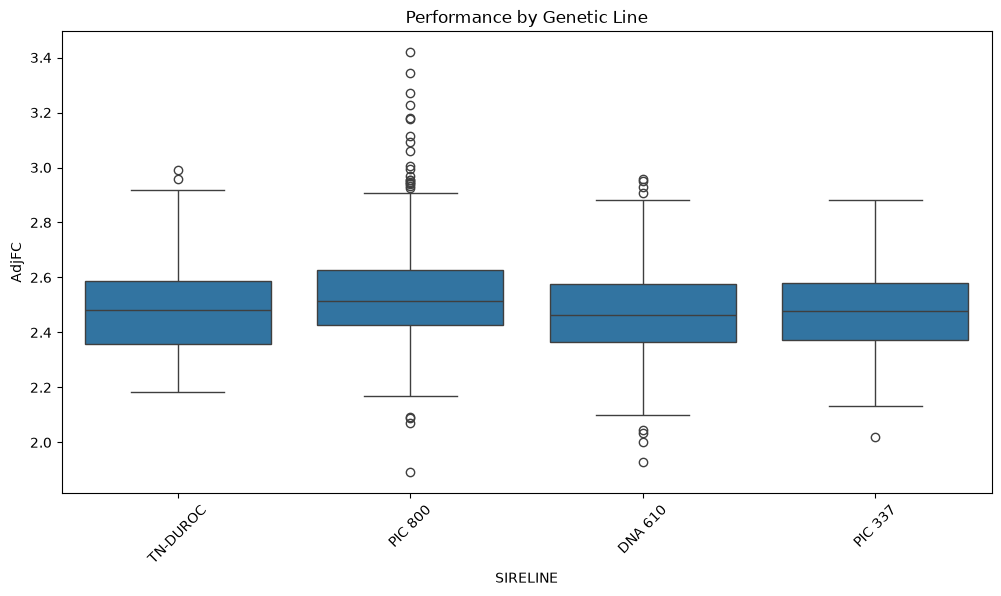

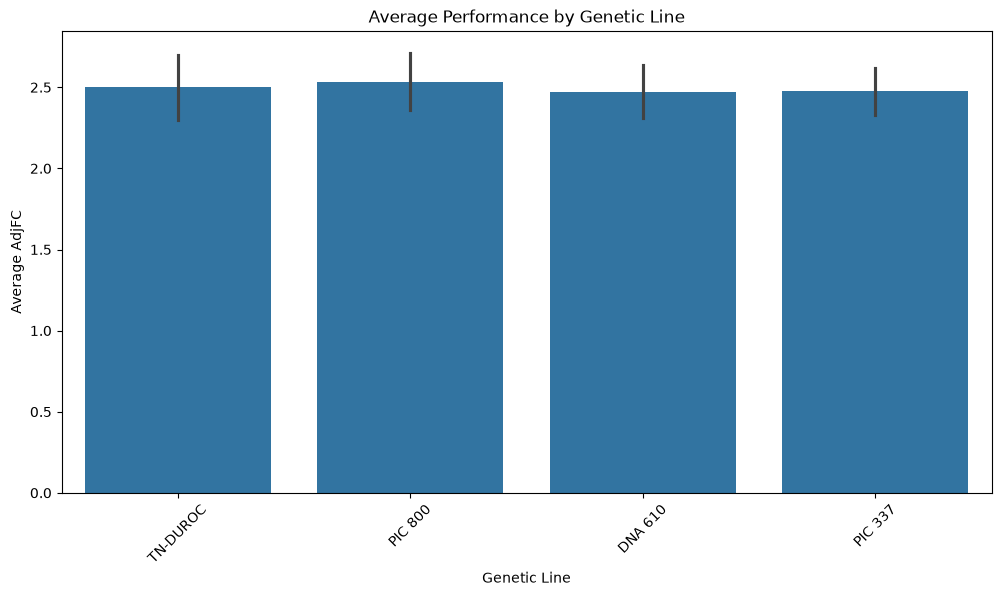

F-statistic: 12.197225724995938
p-value: 7.347242114710572e-08
          count      mean    median       std
SIRELINE                                     
DNA 610     356  2.471231  2.463591  0.163122
PIC 337      92  2.474529  2.478935  0.143412
TN-DUROC     66  2.499152  2.480255  0.199172
PIC 800     644  2.535578  2.515701  0.176872
Best genetic line DNA 610
          count      mean    median       std
SIRELINE                                     
DNA 610     356  2.471231  2.463591  0.163122


In [140]:
#Genetic Line Comparisons - Adjusted Feed Cost

genetic_col = "SIRELINE"
target_col = "AdjFC"

line_summary = df.groupby(genetic_col)[target_col].agg(
    count = 'count',
    mean = 'mean',
    median = 'median',
    st = 'std',
    min = 'min',
    max = 'max',
).sort_values(by = 'mean', ascending=True)
print(line_summary)

#Visualization
plt.figure(figsize = (12,6))
sns.boxplot(data = df, x = genetic_col, y = target_col)
plt.title("Performance by Genetic Line")
plt.ylabel(target_col)
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=df, x=genetic_col, y=target_col, errorbar="sd")
plt.title("Average Performance by Genetic Line")
plt.xlabel("Genetic Line")
plt.ylabel(f"Average {target_col}")
plt.xticks(rotation=45)
plt.show()

#Testing whether statistically significant
from scipy.stats import f_oneway

groups = [
    group[target_col].dropna()
    for name, group in df.groupby(genetic_col)
]

f_stat3, p_value3 = f_oneway(*groups)


print("F-statistic:", f_stat3)
print("p-value:", p_value3)

#Summary of Genetic Lines
line_summary3 = df.groupby(genetic_col)[target_col].agg(
    count="count",
    mean="mean",
    median="median",
    std="std"
)
line_summary3 = line_summary3[line_summary3["count"] >= 5]

line_summary3 = line_summary3.sort_values(by="mean", ascending=True)


print(line_summary3)

best_line = line_summary3.index[0]
print("Best genetic line", best_line)


#top performer
print(line_summary3.head(1))

          count      mean    median        st       min       max
SIRELINE                                                         
PIC 337      92  0.919975  0.921534  0.045268  0.770415  1.000000
DNA 610     356  0.912247  0.920033  0.058049  0.604585  1.000000
PIC 800     644  0.911622  0.918989  0.068651  0.390049  1.000000
TN-DUROC     66  0.873011  0.888431  0.072535  0.665597  0.983549


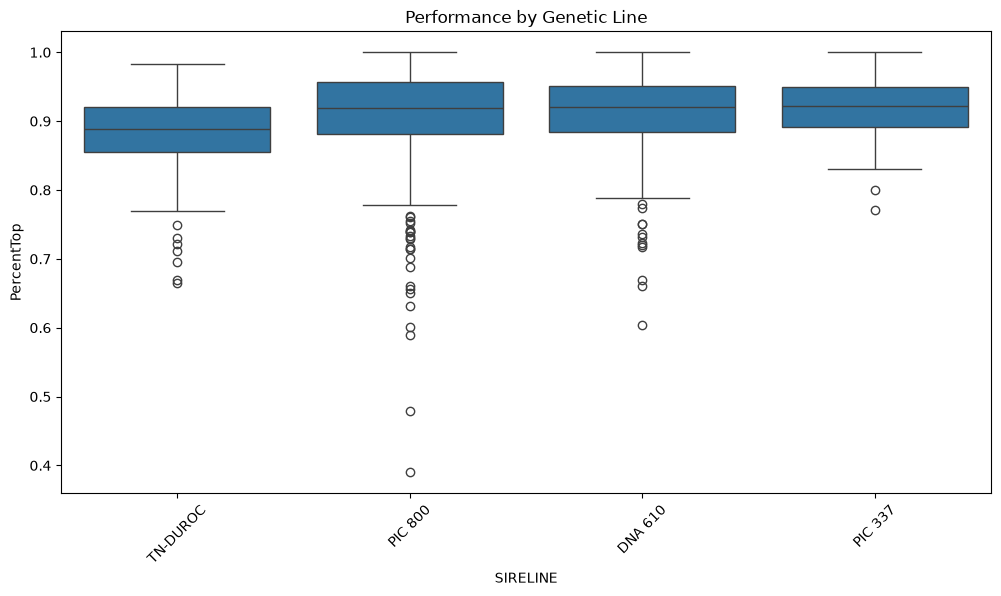

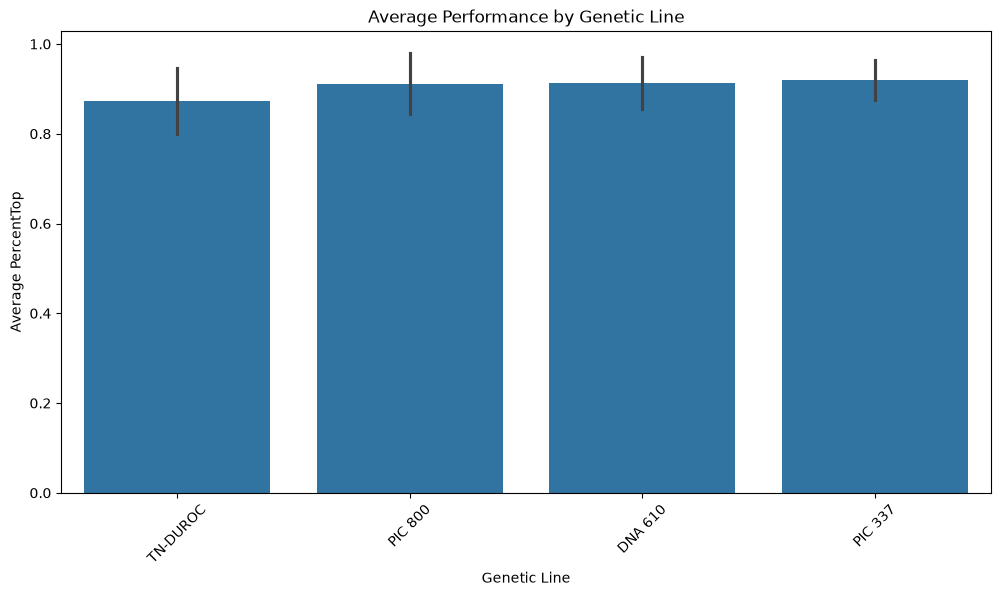

F-statistic: 8.320730281259145
p-value: 1.778150575452762e-05
          count      mean    median       std
SIRELINE                                     
PIC 337      92  0.919975  0.921534  0.045268
DNA 610     356  0.912247  0.920033  0.058049
PIC 800     644  0.911622  0.918989  0.068651
TN-DUROC     66  0.873011  0.888431  0.072535
Best genetic line PIC 337
          count      mean    median       std
SIRELINE                                     
PIC 337      92  0.919975  0.921534  0.045268


In [141]:
#Genetic Line Comparisons - Tops percentage

genetic_col = "SIRELINE"
target_col = "PercentTop"

line_summary = df.groupby(genetic_col)[target_col].agg(
    count = 'count',
    mean = 'mean',
    median = 'median',
    st = 'std',
    min = 'min',
    max = 'max',
).sort_values(by = 'mean', ascending=False)
print(line_summary)

#Visualization
plt.figure(figsize = (12,6))
sns.boxplot(data = df, x = genetic_col, y = target_col)
plt.title("Performance by Genetic Line")
plt.ylabel(target_col)
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=df, x=genetic_col, y=target_col, errorbar="sd")
plt.title("Average Performance by Genetic Line")
plt.xlabel("Genetic Line")
plt.ylabel(f"Average {target_col}")
plt.xticks(rotation=45)
plt.show()

#Testing whether statistically significant
from scipy.stats import f_oneway

groups = [
    group[target_col].dropna()
    for name, group in df.groupby(genetic_col)
]

f_stat4, p_value4 = f_oneway(*groups)


print("F-statistic:", f_stat4)
print("p-value:", p_value4) 

#Summary of Genetic Lines
line_summary4 = df.groupby(genetic_col)[target_col].agg(
    count="count",
    mean="mean",
    median="median",
    std="std"
)
line_summary4 = line_summary4[line_summary4["count"] >= 5]

line_summary4 = line_summary4.sort_values(by="mean", ascending=False)


print(line_summary4)

best_line = line_summary4.index[0]
print("Best genetic line", best_line)


#top performer
print(line_summary4.head(1))

**Best Sire Line by Mortality Percentage:**

In [142]:
print(line_summary1.head(1))
print("F-statistic:", f_stat1)
print("p-value:", p_value1) 

          count      mean    median       std
SIRELINE                                     
PIC 337      92  0.061506  0.058636  0.024588
F-statistic: 13.95304398224835
p-value: 6.120233282703152e-09


**Best Sire Line by Average Daily Gain:**

In [143]:
print(line_summary2.head(1))
print("F-statistic:", f_stat2)
print("p-value:", p_value2) 

          count      mean    median       std
SIRELINE                                     
DNA 610     356  1.795199  1.794413  0.127109
F-statistic: 21.710214372760728
p-value: 1.1103540367109733e-13


**Best Sire Line by Feed Conversion:**

In [144]:
print(line_summary3.head(1))
print("F-statistic:", f_stat3)
print("p-value:", p_value3) 

          count      mean    median       std
SIRELINE                                     
DNA 610     356  2.471231  2.463591  0.163122
F-statistic: 12.197225724995938
p-value: 7.347242114710572e-08


**Best Sire Line by Tops Percentage:**

In [145]:
print(line_summary4.head(1))
print("F-statistic:", f_stat4)
print("p-value:", p_value4) 

          count      mean    median       std
SIRELINE                                     
PIC 337      92  0.919975  0.921534  0.045268
F-statistic: 8.320730281259145
p-value: 1.778150575452762e-05


All are statistically significant: *ANOVA P-Values* < 0.05 <br>
At least one SIRELINE mean is statistically different from the others


In [ ]:
newcols = ['DNA 610', 'PIC 800', 'TN DUROC', 'PIC 337', 'P-Value', 'F-Stat']
results = pd.DataFrame(columns = newcols)

#Based on Means
results.loc[len(results)] = [line_summary1['mean']['DNA 610'], line_summary1['mean']['PIC 800'], line_summary1['mean']['TN-DUROC'], line_summary1['mean']['PIC 337'], p_value1, f_stat1]
results.loc[len(results)] = [line_summary2['mean']['DNA 610'], line_summary2['mean']['PIC 800'], line_summary2['mean']['TN-DUROC'], line_summary2['mean']['PIC 337'], p_value2, f_stat2]
results.loc[len(results)] = [line_summary3['mean']['DNA 610'], line_summary3['mean']['PIC 800'], line_summary3['mean']['TN-DUROC'], line_summary3['mean']['PIC 337'], p_value3, f_stat3]
results.loc[len(results)] = [line_summary4['mean']['DNA 610'], line_summary4['mean']['PIC 800'], line_summary4['mean']['TN-DUROC'], line_summary4['mean']['PIC 337'], p_value4, f_stat4]


results.index = ['Mort', 'ADG', 'FC', 'Tops']

results.to_csv("SireLineSignificance.csv")
